# Quantum Walk Feature Expansion for Binary Classification

A discrete-time quantum walk (DTQW) used as a **feature expansion mechanism**,
compared against classical baselines.

Pure NumPy state-vector simulation — no Qiskit, no PennyLane. One independent
quantum walk is run per dataset row.

```
features -> select k -> scale to parameter ranges -> map to walk parameters
         -> build |psi_0> -> run T steps -> extract features -> ML model
```

**This notebook is entirely self-contained.** Everything below runs from these
cells alone.

---

## Fixed physics

The coin operator, exactly as specified:

$$C(\alpha, \beta) = \begin{pmatrix} \cos\alpha\, e^{i\beta} & \sin\alpha \\ -\sin\alpha & \cos\alpha\, e^{-i\beta} \end{pmatrix}$$

The initial coin state:

$$|\text{coin}_0\rangle = \cos(\theta/2)\,|0\rangle + e^{i\phi}\sin(\theta/2)\,|1\rangle$$

One walk step, coin first and then shift:

$$|\psi_{t+1}\rangle = S\,C\,|\psi_t\rangle$$

The shift $S$ moves coin state $|0\rangle$ **left** and coin state $|1\rangle$
**right**. The position readout sums over coin states:

$$P_T(x) = \sum_{c\in\{0,1\}} \big|\langle x, c\,|\,\psi_T\rangle\big|^2$$

**1D parameters** (exactly 4, so exactly 4 features are selected):

| parameter | range |
|---|---|
| $\theta$ | $[0, \pi]$ |
| $\phi$ | $[0, 2\pi]$ |
| $\alpha$ | $[0, \pi/2]$ |
| $\beta$ | $[0, 2\pi]$ |

Section 3 verifies the physics numerically before any classification is done.

## 1. Imports and configuration

Every knob lives in this one cell. Nothing further down uses a bare literal.

In [1]:
import itertools
import pathlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import (
    GridSearchCV, StratifiedKFold, cross_val_score, train_test_split,
)
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import (
    FunctionTransformer, MinMaxScaler, PolynomialFeatures, StandardScaler,
)
from sklearn.utils.validation import check_is_fitted

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams.update({"figure.figsize": (9, 4), "figure.dpi": 110,
                     "axes.grid": True, "grid.alpha": 0.3, "font.size": 10})

In [2]:
# ============================ CONFIGURATION ============================
SEED = 42                 # the single seed; nothing else is random
DATASET = "diabetes"      # "diabetes" | "breast_cancer" | "spam"
N_STEPS = 25              # walk steps T
TEST_SIZE = 0.3           # stratified hold-out fraction
POLY_DEGREE = 2           # degree for the polynomial baseline
SELECTOR = "mutual_info"  # "mutual_info" | "anova_f" | "tree"
PERMUTATION = (0, 1, 2, 3)  # which selected feature drives which parameter

PARAM_NAMES = ("theta", "phi", "alpha", "beta")
PARAM_RANGES = ((0.0, np.pi),         # theta
                (0.0, 2.0 * np.pi),   # phi
                (0.0, np.pi / 2.0),   # alpha
                (0.0, 2.0 * np.pi))   # beta
N_PARAMS = len(PARAM_NAMES)           # == 4, and == the number of features selected
N_WALK_FEATURES = 10                  # width of extract_features output

FEATURE_NAMES = ("mean", "std", "skew", "kurtosis", "entropy",
                 "ipr", "p_max", "argmax_x", "p_left", "p_origin")
SPACES = ("original", "polynomial", "qw", "original+qw")
# =======================================================================

assert len(PARAM_RANGES) == N_PARAMS
assert sorted(PERMUTATION) == list(range(N_PARAMS)), "PERMUTATION must be a rearrangement of 0..3"

def describe_permutation(perm):
    """Render a permutation as 'theta<-f2 phi<-f0 ...' for logging."""
    return " ".join(f"{n}<-f{s}" for n, s in zip(PARAM_NAMES, perm))

print(f"seed={SEED}  dataset={DATASET}  T={N_STEPS}  k={N_PARAMS}  selector={SELECTOR}")
print(f"permutation={list(PERMUTATION)}  [{describe_permutation(PERMUTATION)}]")

seed=42  dataset=diabetes  T=25  k=4  selector=mutual_info
permutation=[0, 1, 2, 3]  [theta<-f0 phi<-f1 alpha<-f2 beta<-f3]


## 2. Data

Any of the three datasets can be selected from the config cell above. The CSV is
looked for next to the notebook first; if it is not found, the notebook falls
back to scikit-learn's built-in Breast Cancer Wisconsin so it always runs.

In [3]:
DATASETS = {
    "diabetes":      dict(file="diabetes.csv", target="Outcome",   drop=[],     positive=None),
    "breast_cancer": dict(file="data.csv",     target="diagnosis", drop=["id"], positive="M"),
    "spam":          dict(file="spambase.csv", target="spam",      drop=[],     positive=None),
}

SEARCH_DIRS = [pathlib.Path("."), pathlib.Path("data"),
               pathlib.Path.home() / "Downloads", pathlib.Path("..")]

def find_csv(filename):
    """Look for the dataset CSV in a few obvious places."""
    for d in SEARCH_DIRS:
        p = d / filename
        if p.is_file():
            return p
    return None

def load_data(name=DATASET):
    """Return (X, y, feature_names, class_names) as plain NumPy."""
    spec = DATASETS[name]
    path = find_csv(spec["file"])
    if path is None:
        print(f"'{spec['file']}' not found -> falling back to sklearn Breast Cancer Wisconsin")
        b = load_breast_cancer()
        return (np.asarray(b.data, float), np.asarray(b.target, int),
                tuple(b.feature_names), tuple(b.target_names))

    df = pd.read_csv(path)
    df = df.drop(columns=[c for c in spec["drop"] if c in df.columns])
    df = df.loc[:, ~df.columns.str.startswith("Unnamed")]
    y_raw = df[spec["target"]]
    X_df = df.drop(columns=[spec["target"]]).apply(pd.to_numeric, errors="coerce")
    X_df = X_df.fillna(X_df.median())
    if spec["positive"] is not None:
        y = (y_raw.astype(str).str.strip() == spec["positive"]).astype(int).to_numpy()
        classes = (f"not {spec['positive']}", spec["positive"])
    else:
        y = y_raw.astype(int).to_numpy()
        classes = ("negative", "positive")
    print(f"loaded {path}")
    return X_df.to_numpy(float), y, tuple(X_df.columns), classes


X, y, FEATURE_LABELS, CLASS_NAMES = load_data()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y
)

print(f"shape={X.shape}  classes={CLASS_NAMES}")
print(f"train={X_train.shape[0]}  test={X_test.shape[0]}")
print(f"positive rate: train={y_train.mean():.3f}  test={y_test.mean():.3f}")
print(f"majority-class baseline on test: {max(y_test.mean(), 1 - y_test.mean()):.4f}")

loaded diabetes.csv
shape=(768, 8)  classes=('negative', 'positive')
train=537  test=231
positive rate: train=0.348  test=0.351
majority-class baseline on test: 0.6494


## 3. The quantum walk

### The lattice grows with the walk

The walker starts on a **single site**. Each step the lattice grows by two
sites: coin $|0\rangle$ keeps its index while coin $|1\rangle$ advances by two,
which in the frame that gains one site on each side per step is exactly "coin
$|0\rangle$ moves left, coin $|1\rangle$ moves right".

After $T$ steps the array is $2T+1$ sites — **exactly the light cone**. The
physical position of index $j$ is $x = j - T$.

Nothing is padded and nothing is rolled, so probability cannot wrap around the
array or fall off its end. The alternative — a fixed array with a periodic
shift — needs padding and a proof that the padding is wide enough; growing the
lattice removes that class of bug entirely.

> The classic failure mode is starting the walker at index 0 of a fixed array
> with a non-periodic shift: probability then falls off the edge every step and
> $\sum_x P_T(x)$ decays away from 1, breaking unitarity and acceptance
> criterion §20.6.

In [4]:
def n_positions_for(n_steps):
    """Lattice size after T steps: exactly the light cone, 2*T + 1 sites."""
    return 2 * int(n_steps) + 1

def position_axis(n_positions):
    """Integer positions x for a lattice of n_positions sites, centred on 0."""
    return np.arange(n_positions, dtype=float) - (n_positions // 2)

def coin_operator(alpha, beta):
    """C(alpha, beta) for one sample, exactly as specified. Returns (2, 2)."""
    return np.array([[np.cos(alpha) * np.exp(1j * beta), np.sin(alpha)],
                     [-np.sin(alpha), np.cos(alpha) * np.exp(-1j * beta)]], dtype=complex)

# def run_qw_1d(theta, phi, alpha, beta, n_steps):
#     """Run one independent 1D walk per sample, vectorised over samples.

#     The lattice starts as one site and grows by two per step, so it is always
#     exactly the light cone: 2*n_steps + 1 sites. Nothing is padded, nothing is
#     rolled, so no probability can wrap or be lost.

#     Returns psi of shape (n_samples, 2*n_steps + 1, 2), where psi[s, j, c] is
#     the amplitude of sample s at lattice index j with coin state c. The physical
#     position of index j is x = j - n_steps, which is what position_axis returns.
#     """
#     theta, phi, alpha, beta = (np.atleast_1d(np.asarray(v, float))
#                                for v in (theta, phi, alpha, beta))
#     if not (theta.shape == phi.shape == alpha.shape == beta.shape):
#         raise ValueError("theta, phi, alpha, beta must share the same shape")
#     if n_steps < 0:
#         raise ValueError("n_steps must be non-negative")

#     n_samples = theta.shape[0]

#     # |psi_0> = |x=0> (x) (cos(theta/2)|0> + e^{i phi} sin(theta/2)|1>)
#     psi = np.zeros((n_samples, 1, 2), dtype=np.complex128)
#     psi[:, 0, 0] = np.cos(theta / 2.0)
#     psi[:, 0, 1] = np.exp(1j * phi) * np.sin(theta / 2.0)

#     # C(alpha, beta) as four broadcastable columns, one 2x2 per sample
#     cos_a, sin_a = np.cos(alpha)[:, None], np.sin(alpha)[:, None]
#     c00 = cos_a * np.exp(1j * beta)[:, None]
#     c01 = sin_a.astype(np.complex128)
#     c10 = -sin_a.astype(np.complex128)
#     c11 = cos_a * np.exp(-1j * beta)[:, None]

#     for _ in range(n_steps):
#         up, down = psi[:, :, 0], psi[:, :, 1]
#         coined_up = c00 * up + c01 * down
#         coined_down = c10 * up + c11 * down
#         # Grow by two sites. Coin |0> keeps its index, coin |1> advances by two;
#         # in the growing frame that is "coin |0> left, coin |1> right".
#         grown = np.zeros((n_samples, psi.shape[1] + 2, 2), dtype=np.complex128)
#         grown[:, :-2, 0] = coined_up
#         grown[:, 2:, 1] = coined_down
#         psi = grown
#     return psi

def move(space):
    """Move the walker one step to the left/right in the growing lattice."""
    new_space = np.zeros([len(space) + 2, 2], dtype=complex)

    for i in range(len(space)):
        new_space[i][0] = space[i][0]
        new_space[i + 2][1] = space[i][1]

    return new_space


def create_coin_operator(alpha, beta):
    """Create the 2x2 coin operator C(alpha, beta)."""
    return np.array([
        [np.cos(alpha) * np.exp(1j * beta), np.sin(alpha)],
        [-np.sin(alpha), np.cos(alpha) * np.exp(-1j * beta)]
    ], dtype=complex)


def run_qw_1d(theta, phi, alpha, beta, num_steps):
    """Run a single 1D quantum walk."""
    coin = create_coin_operator(alpha, beta)

    # Initial state:
    # |psi_0> = |x=0> ⊗
    # [cos(theta/2), exp(i*phi) sin(theta/2)]
    state = np.array([
        [np.cos(theta / 2),
         np.exp(1j * phi) * np.sin(theta / 2)]
    ], dtype=complex)

    print(f"Number of steps: {num_steps}")
    for _ in range(num_steps):
        # Apply coin operator to every position
        for i in range(len(state)):
            state[i] = coin @ state[i]

        # Apply conditional movement
        state = move(state)

    # Probability for each coin state
    prob = np.abs(state) ** 2

    # Physical positions
    positions = np.arange(-num_steps, num_steps + 1)

    # Sum over coin states
    probabilities = prob.sum(axis=1)

    return probabilities


def position_probabilities(psi):
    """P_T(x) = sum_c |psi[s, x, c]|^2, shape (n_samples, n_positions)."""
    return np.sum(np.abs(psi) ** 2, axis=-1)

In [5]:
import contextlib
import io

def run_qw_1d_batch(theta, phi, alpha, beta, n_steps):
    """Call run_qw_1d once per row and stack the results.

    run_qw_1d only handles one walker per call and already returns P_T(x)
    (real, summed over coin state) rather than the complex amplitudes psi --
    so this returns an (n_samples, n_positions) probability array, not a
    (n_samples, n_positions, 2) amplitude array. Its per-step print is
    suppressed here (not inside run_qw_1d) so a few hundred rows don't turn
    into a few hundred thousand printed lines.
    """
    theta = np.atleast_1d(np.asarray(theta, dtype=float))
    phi = np.atleast_1d(np.asarray(phi, dtype=float))
    alpha = np.atleast_1d(np.asarray(alpha, dtype=float))
    beta = np.atleast_1d(np.asarray(beta, dtype=float))
    n_positions = 2 * int(n_steps) + 1
    probs = np.empty((len(theta), n_positions), dtype=float)
    with contextlib.redirect_stdout(io.StringIO()):
        for i in range(len(theta)):
            probs[i] = run_qw_1d(float(theta[i]), float(phi[i]),
                                 float(alpha[i]), float(beta[i]), n_steps)
    return probs

### Feature extraction

Each final distribution $P_T(x)$ collapses to 10 numbers: four statistical
moments, Shannon entropy, the inverse participation ratio (a localisation
measure), the peak height and its position, and two direct probability readings.

In [6]:
def extract_features(prob):
    """Summarise each sample's final position distribution. Returns (n_samples, 10).

    Takes P_T(x) directly (shape (n_samples, n_positions)) -- run_qw_1d_batch
    already returns probabilities, not complex amplitudes.
    """
    x = position_axis(prob.shape[1])

    mean = prob @ x
    dx = x[None, :] - mean[:, None]
    var = np.sum(prob * dx ** 2, axis=1)
    std = np.sqrt(var)
    safe = np.where(std > 0, std, 1.0)
    skew = np.sum(prob * dx ** 3, axis=1) / safe ** 3
    kurt = np.sum(prob * dx ** 4, axis=1) / safe ** 4

    entropy = -np.sum(prob * np.log(np.where(prob > 0, prob, 1.0)), axis=1)
    ipr = np.sum(prob ** 2, axis=1)          # localisation
    p_max = np.max(prob, axis=1)
    argmax_x = x[np.argmax(prob, axis=1)]
    p_left = np.sum(prob[:, x < 0], axis=1)
    p_origin = prob[:, np.argmin(np.abs(x))]

    return np.column_stack([mean, std, skew, kurt, entropy,
                            ipr, p_max, argmax_x, p_left, p_origin])

## 4. Physics validation

These checks run before any machine learning. If any of them fails, nothing
downstream is meaningful.

1. **Norm preservation** — $\sum_x P_T(x) = 1$ to within $10^{-10}$, at several $T$.
2. **Hadamard check** — $\alpha=\pi/4,\ \beta=0,\ \theta=0,\ \phi=0$ at $T=30$
   must put the dominant peak near $x = -0.7T$.
3. **Light cone** — the lattice is exactly $2T+1$ sites, and the amplitudes at
   its two tips match the closed form for the single path that reaches them.
   (With a growing lattice there is no periodic shift, so wraparound is
   impossible by construction; this checks the shift bookkeeping instead.)
4. **Initial state** and **coin unitarity** — the operators match the spec.

In [7]:
def _random_params(n, seed=0):
    rng = np.random.default_rng(seed)
    return tuple(rng.uniform(lo, hi, n) for lo, hi in PARAM_RANGES)

def run_physics_checks(tol=1e-8, verbose=True):
    """Assert the fixed physics, working only from run_qw_1d's probability output.

    run_qw_1d returns P_T(x) (real, already summed over coin state), not the
    complex amplitudes psi -- so checks that need coin-resolved or phase
    information are rewritten to verify the same physics through probabilities
    only, rather than inspecting amplitudes directly.
    """
    results = []

    # 1. norm preservation
    worst = 0.0
    for T in [0, 1, 2, 5, 15, 30, 50]:
        prob = run_qw_1d_batch(*_random_params(16, seed=T), T)
        worst = max(worst, float(np.abs(prob.sum(axis=1) - 1).max()))
    results.append(("norm preservation, sum P_T(x) == 1", worst < tol, f"max deviation {worst:.2e}"))

    # 2. Hadamard peak near -0.7*T
    T = 30
    z = np.array([0.0])
    p = run_qw_1d_batch(z, z, np.array([np.pi / 4]), z, T)[0]
    xs = position_axis(p.shape[0])
    peak = xs[np.argmax(p)]
    ok = abs(peak - (-0.7 * T)) <= 0.1 * T and p[xs < 0].sum() > p[xs > 0].sum()
    results.append(("Hadamard peak near x = -0.7*T", ok,
                    f"peak x={peak:.0f}, target {-0.7 * T:.1f}, ballistic {-T / np.sqrt(2):.2f}"))

    # 3. lattice is exactly the light cone, and its tips carry the analytic
    # probability. The only path to x=+T is T consecutive coin-|1> moves, so
    # P_T(+T) = |c11^(T-1) * (c10*u0 + c11*d0)|^2; x=-T mirrors it through the
    # coin-|0> row. run_qw_1d discards coin-resolved amplitudes, so this checks
    # the probability the closed form predicts, not the amplitude itself.
    ok, detail = True, ""
    for T in [1, 5, 30, 60]:
        theta, phi, alpha, beta = 0.7, 1.3, 0.9, 2.1
        prob = run_qw_1d_batch(np.array([theta]), np.array([phi]),
                               np.array([alpha]), np.array([beta]), T)[0]
        ok &= prob.shape[0] == 2 * T + 1
        c = coin_operator(alpha, beta)
        u0 = np.cos(theta / 2.0)
        d0 = np.exp(1j * phi) * np.sin(theta / 2.0)
        right = c[1, 1] ** (T - 1) * (c[1, 0] * u0 + c[1, 1] * d0)
        left = c[0, 0] ** (T - 1) * (c[0, 0] * u0 + c[0, 1] * d0)
        ok &= np.isclose(prob[-1], np.abs(right) ** 2, atol=tol)
        ok &= np.isclose(prob[0], np.abs(left) ** 2, atol=tol)
        detail = f"length == 2T+1 and both tip probabilities analytic, up to T={T}"
    results.append(("lattice is exactly the light cone", ok, detail))

    # 4. initial state, via the pure-coin extremes theta=0 and theta=pi.
    # With alpha=0 the coin is diagonal (no mixing), so a pure coin-0 walker
    # (theta=0) stays coin-0 and never advances -> all probability ends at the
    # leftmost site; a pure coin-1 walker (theta=pi) ends entirely at the
    # rightmost site. This exercises theta and the move() logic together but,
    # like check 3, cannot see phi: sin(theta/2)=0 at both extremes kills the
    # e^{i phi} term, so phi has no visible effect on run_qw_1d's output here.
    T = 20
    prob0 = run_qw_1d_batch(np.array([0.0]), np.array([0.0]),
                            np.array([0.0]), np.array([0.0]), T)[0]
    probpi = run_qw_1d_batch(np.array([np.pi]), np.array([0.0]),
                             np.array([0.0]), np.array([0.0]), T)[0]
    # atol=1e-10 here, not the tighter `tol`: cos(pi/2) is ~6.1e-17 rather than
    # exact 0, so theta=pi leaves a ~1e-33 speck of probability off the tip --
    # negligible, but tighter than 1e-10 would flag floating-point noise as a bug.
    ok = (np.isclose(prob0[0], 1.0, atol=tol) and np.all(prob0[1:] < 1e-10)
          and np.isclose(probpi[-1], 1.0, atol=tol) and np.all(probpi[:-1] < 1e-10))
    results.append(("initial coin state matches spec (theta extremes)", ok,
                    "theta=0 -> all mass at x=-T; theta=pi -> all mass at x=+T "
                    "(phi not independently checkable from probabilities alone)"))

    # 5. coin unitarity across the declared range
    rng = np.random.default_rng(7)
    ok = all(np.allclose(coin_operator(a, b).conj().T @ coin_operator(a, b), np.eye(2), atol=tol)
             for a, b in zip(rng.uniform(0, np.pi / 2, 32), rng.uniform(0, 2 * np.pi, 32)))
    results.append(("coin C(a, b) is unitary", ok, "C^dag C == I over the whole range"))

    if verbose:
        for name, passed, detail in results:
            print(f"  [{'PASS' if passed else 'FAIL'}]  {name:<48} {detail}")
    return all(r[1] for r in results)


print("PHYSICS CHECKS")
assert run_physics_checks(), "physics checks failed -- stop here"
print("\nall checks passed")

PHYSICS CHECKS
  [PASS]  norm preservation, sum P_T(x) == 1               max deviation 9.10e-15
  [PASS]  Hadamard peak near x = -0.7*T                    peak x=-20, target -21.0, ballistic -21.21
  [PASS]  lattice is exactly the light cone                length == 2T+1 and both tip probabilities analytic, up to T=60
  [PASS]  initial coin state matches spec (theta extremes) theta=0 -> all mass at x=-T; theta=pi -> all mass at x=+T (phi not independently checkable from probabilities alone)
  [PASS]  coin C(a, b) is unitary                          C^dag C == I over the whole range

all checks passed


### What the walk looks like

The Hadamard walk is ballistic: two peaks travelling outward at $\pm T/\sqrt{2}$,
not a diffusive Gaussian. Parity restricts support to even sites at even $T$.

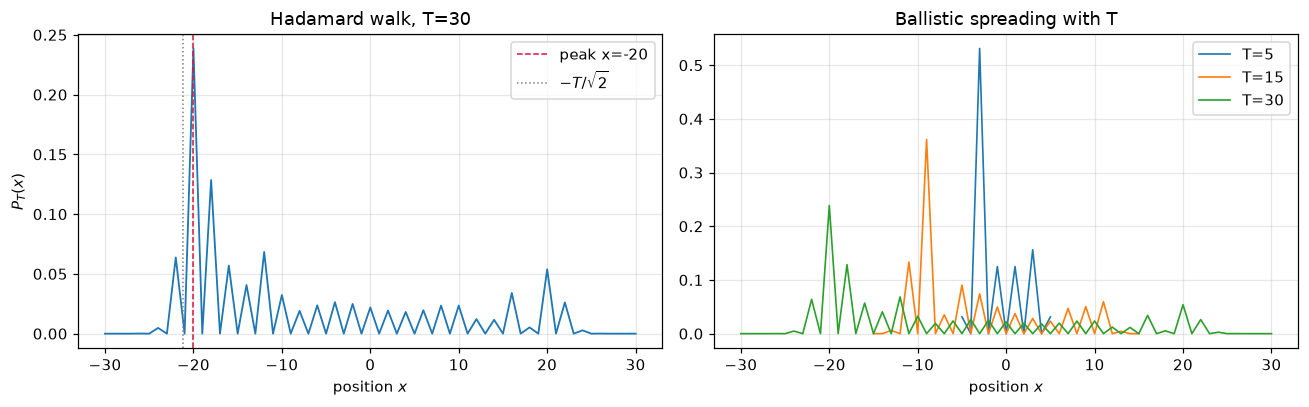

In [8]:
T_demo = 30
z = np.array([0.0])
p_h = run_qw_1d_batch(z, z, np.array([np.pi / 4]), z, T_demo)[0]
x_h = position_axis(p_h.shape[0])
peak = x_h[np.argmax(p_h)]

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(x_h, p_h, lw=1.2)
axes[0].axvline(peak, color="crimson", ls="--", lw=1, label=f"peak x={peak:.0f}")
axes[0].axvline(-T_demo / np.sqrt(2), color="gray", ls=":", lw=1, label=r"$-T/\sqrt{2}$")
axes[0].set_title(f"Hadamard walk, T={T_demo}")
axes[0].set_xlabel("position $x$"); axes[0].set_ylabel("$P_T(x)$"); axes[0].legend()

for T_i in [5, 15, 30]:
    p_i = run_qw_1d_batch(z, z, np.array([np.pi / 4]), z, T_i)[0]
    axes[1].plot(position_axis(p_i.shape[0]), p_i, lw=1.1, label=f"T={T_i}")
axes[1].set_title("Ballistic spreading with T")
axes[1].set_xlabel("position $x$"); axes[1].legend()
plt.tight_layout(); plt.show()

## 5. Feature selection and the parameter mapping

Exactly `N_PARAMS` features are selected, one per walk parameter. Three methods
are available and the choice is a config knob.

In [9]:
def tree_importance(X_, y_, seed=SEED):
    """Impurity-based importances from a seeded extra-trees ensemble."""
    return ExtraTreesClassifier(n_estimators=300, random_state=seed,
                               n_jobs=-1).fit(X_, y_).feature_importances_

def make_selector(name=SELECTOR, k=N_PARAMS, seed=SEED):
    """Unfitted SelectKBest keeping exactly k features."""
    if name == "mutual_info":
        score = lambda X_, y_: mutual_info_classif(X_, y_, random_state=seed)
    elif name == "anova_f":
        score = f_classif
    elif name == "tree":
        score = lambda X_, y_: tree_importance(X_, y_, seed)
    else:
        raise KeyError(f"unknown selector {name!r}")
    return SelectKBest(score_func=score, k=k)

### No test-set leakage, by construction

`QuantumWalkFeatures` owns the selector **and** the `MinMaxScaler`, and fits both
inside its `fit()`. Because it is a scikit-learn transformer it sits inside a
`Pipeline` with the classifier, so the test set can only ever reach `transform()`
and `predict()` — leakage becomes structurally impossible rather than a matter of
discipline.

The scaler uses `clip=True`, so a test row outside the training range still lands
inside the declared parameter interval without the scaler ever being refitted.

In [10]:
class QuantumWalkFeatures(BaseEstimator, TransformerMixin):
    """Expand each row into walk features via one independent quantum walk.

        select k -> min-max to [0,1] -> permute -> scale to ranges
                 -> build |psi_0> -> T steps -> extract 10 features
    """

    def __init__(self, n_steps=N_STEPS, permutation=PERMUTATION,
                 selector=SELECTOR, seed=SEED):
        self.n_steps = n_steps
        self.permutation = permutation
        self.selector = selector
        self.seed = seed

    def fit(self, X_, y_):
        """Fit the selector and the scaler. Only ever sees training rows."""
        X_ = np.asarray(X_, float)
        perm = tuple(int(i) for i in self.permutation)
        if sorted(perm) != list(range(N_PARAMS)):
            raise ValueError(f"permutation must rearrange 0..{N_PARAMS - 1}, got {list(perm)}")
        self.permutation_ = perm
        self.selector_ = make_selector(self.selector, N_PARAMS, self.seed).fit(X_, y_)
        self.indices_ = self.selector_.get_support(indices=True)
        self.scaler_ = MinMaxScaler(clip=True).fit(X_[:, self.indices_])
        self.n_features_in_ = X_.shape[1]
        return self

    def walk_parameters(self, X_):
        """Physical walk parameters per row, for inspection. Returns (n, 4)."""
        check_is_fitted(self, "scaler_")
        unit = self.scaler_.transform(np.asarray(X_, float)[:, self.indices_])
        unit = unit[:, list(self.permutation_)]
        lo = np.array([r[0] for r in PARAM_RANGES])
        hi = np.array([r[1] for r in PARAM_RANGES])
        return lo + unit * (hi - lo)

    def transform(self, X_):
        """Run the walks and return the extracted features. Returns (n, 10)."""
        p = self.walk_parameters(X_)
        return extract_features(run_qw_1d_batch(p[:, 0], p[:, 1], p[:, 2], p[:, 3], self.n_steps))

    def get_feature_names_out(self, input_features=None):
        return np.array([f"qw_{i:02d}" for i in range(N_WALK_FEATURES)], dtype=object)

    def describe(self):
        """Log line naming the selected features and the permutation applied."""
        check_is_fitted(self, "scaler_")
        assign = " ".join(f"{n}<-x{self.indices_[s]}"
                          for n, s in zip(PARAM_NAMES, self.permutation_))
        return (f"selector={self.selector} selected={[int(i) for i in self.indices_]} "
                f"perm={list(self.permutation_)} [{assign}] T={self.n_steps}")

In [11]:
qw = QuantumWalkFeatures().fit(X_train, y_train)
print(qw.describe())
print()
for name, src in zip(PARAM_NAMES, qw.permutation_):
    print(f"  {name:<6} <- x{qw.indices_[src]:<3} {FEATURE_LABELS[qw.indices_[src]]}")

params = qw.walk_parameters(X_train)
print()
for i, (name, (lo, hi)) in enumerate(zip(PARAM_NAMES, PARAM_RANGES)):
    print(f"  {name:<6} declared [{lo:.3f}, {hi:.3f}]   observed [{params[:, i].min():.3f}, {params[:, i].max():.3f}]")

p_test = qw.walk_parameters(X_test)
assert all(p_test[:, i].min() >= lo - 1e-12 and p_test[:, i].max() <= hi + 1e-12
           for i, (lo, hi) in enumerate(PARAM_RANGES))
print("\ntest rows stay inside every declared range")

norms = run_qw_1d_batch(params[:, 0], params[:, 1], params[:, 2], params[:, 3], N_STEPS).sum(axis=1)
print(f"norm across all {len(norms)} training walks: "
      f"max deviation from 1 = {np.abs(norms - 1).max():.2e}")

selector=mutual_info selected=[1, 3, 4, 5] perm=[0, 1, 2, 3] [theta<-x1 phi<-x3 alpha<-x4 beta<-x5] T=25

  theta  <- x1   Glucose
  phi    <- x3   SkinThickness
  alpha  <- x4   Insulin
  beta   <- x5   BMI

  theta  declared [0.000, 3.142]   observed [0.000, 3.142]
  phi    declared [0.000, 6.283]   observed [0.000, 6.283]
  alpha  declared [0.000, 1.571]   observed [0.000, 1.571]
  beta   declared [0.000, 6.283]   observed [0.000, 6.283]

test rows stay inside every declared range


norm across all 537 training walks: max deviation from 1 = 8.22e-15

## 6. The four feature spaces

Each space is a *transformer*, not a matrix, so it is fitted inside the same
`Pipeline` as the classifier. `original+qw` is a `FeatureUnion`, which
concatenates columns: the original features first, then the 10 walk features.

In [12]:
def identity_transformer():
    return FunctionTransformer(feature_names_out="one-to-one")

def build_space(name, n_steps=N_STEPS, permutation=PERMUTATION,
                selector=SELECTOR, seed=SEED, poly_degree=POLY_DEGREE):
    """Unfitted transformer mapping the raw design matrix to one feature space."""
    qw_ = lambda: QuantumWalkFeatures(n_steps, permutation, selector, seed)
    if name == "original":
        return identity_transformer()
    if name == "polynomial":
        return PolynomialFeatures(degree=poly_degree, include_bias=False)
    if name == "qw":
        return qw_()
    if name == "original+qw":
        return FeatureUnion([("original", identity_transformer()), ("qw", qw_())])
    raise KeyError(f"unknown space {name!r}; available: {list(SPACES)}")

def make_model(seed=SEED):
    """The classifier: a scaler and logistic regression in a Pipeline."""
    return Pipeline([("scale", StandardScaler()),
                     ("clf", LogisticRegression(max_iter=5000, random_state=seed))])

def evaluate_space(name, **kw):
    """Fit on train, score on test, for exactly one feature space."""
    pipe = Pipeline([("space", build_space(name, **kw)), ("model", make_model())])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    return {
        "space": name,
        "dims": int(pipe.named_steps["space"].transform(X_train[:1]).shape[1]),
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "pipeline": pipe,
    }

def results_table(rows):
    """Fixed-width table, best accuracy marked with *."""
    head = f"{'space':<14}{'dims':>6}{'accuracy':>11}{'f1':>9}{'precision':>11}{'recall':>9}"
    out = [head, "-" * len(head)]
    best = max(r["accuracy"] for r in rows)
    for r in rows:
        out.append(f"{r['space']:<14}{r['dims']:>6}{r['accuracy']:>11.4f}"
                   f"{r['f1']:>9.4f}{r['precision']:>11.4f}{r['recall']:>9.4f}"
                   f"{' *' if r['accuracy'] == best else ''}")
    return "\n".join(out)

## 7. Results

Same model, same split, same seed, same metrics. Only the feature matrix varies.

In [13]:
results = [evaluate_space(s) for s in SPACES]
print(f"dataset={DATASET}  T={N_STEPS}  perm={list(PERMUTATION)}  selector={SELECTOR}\n")
print(results_table(results))

dataset=diabetes  T=25  perm=[0, 1, 2, 3]  selector=mutual_info

space           dims   accuracy       f1  precision   recall
------------------------------------------------------------
original           8     0.7489   0.6184     0.6620   0.5802
polynomial        44     0.8225   0.7248     0.7941   0.6667
qw                10     0.8485   0.7682     0.8286   0.7160
original+qw       18     0.8528   0.7821     0.8133   0.7531 *


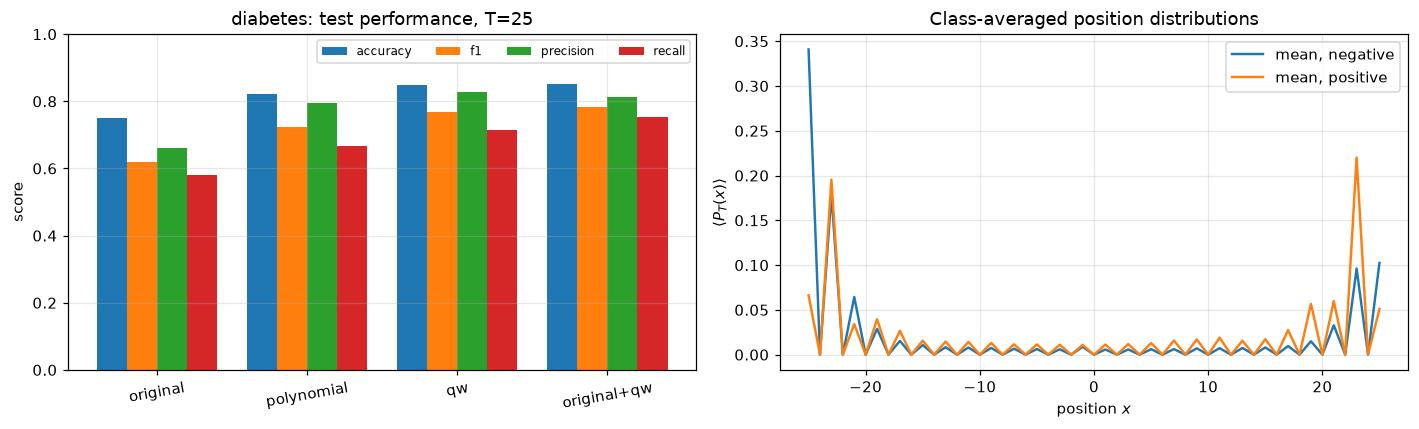

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

metrics = ["accuracy", "f1", "precision", "recall"]
pos, width = np.arange(len(SPACES)), 0.2
for i, m in enumerate(metrics):
    axes[0].bar(pos + i * width, [r[m] for r in results], width, label=m)
axes[0].set_xticks(pos + 1.5 * width)
axes[0].set_xticklabels([r["space"] for r in results], rotation=10)
axes[0].set_ylim(0, 1.0); axes[0].set_ylabel("score")
axes[0].set_title(f"{DATASET}: test performance, T={N_STEPS}")
axes[0].legend(ncol=4, fontsize=8)

prob_tr = run_qw_1d_batch(params[:, 0], params[:, 1], params[:, 2], params[:, 3], N_STEPS)
xs = position_axis(prob_tr.shape[1])
for cls, nm in enumerate(CLASS_NAMES):
    axes[1].plot(xs, prob_tr[y_train == cls].mean(axis=0), lw=1.6, label=f"mean, {nm}")
axes[1].set_xlabel("position $x$"); axes[1].set_ylabel(r"$\langle P_T(x)\rangle$")
axes[1].set_title("Class-averaged position distributions"); axes[1].legend()
plt.tight_layout(); plt.show()

## 8. Joint search over the permutation and $T$

Two things are free: which feature drives which parameter ($4! = 24$ choices),
and the walk length $T$. Tuning them one after the other biases the result, so
they are searched **jointly** in a single `GridSearchCV`, scored by
**cross-validation on the training set only**. The held-out set is read once,
afterwards, for the winner.

> **This matters.** Looping over the grid and keeping whichever scores best *on
> the test set* is selection leakage: the reported number is then the maximum of
> many noisy draws, not an estimate of generalisation. The gap it would have
> opened is measured below.

In [15]:
ALL_PERMS = list(itertools.permutations(range(N_PARAMS)))
T_GRID = [3, 5, 10, 15, 25, 40, 60]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

search = GridSearchCV(
    Pipeline([("space", build_space("original+qw")), ("model", make_model())]),
    param_grid={"space__qw__permutation": ALL_PERMS, "space__qw__n_steps": T_GRID},
    scoring="accuracy", cv=cv, n_jobs=-1,
)
search.fit(X_train, y_train)
best_perm = tuple(search.best_params_["space__qw__permutation"])
best_T = int(search.best_params_["space__qw__n_steps"])

print(f"searched {len(ALL_PERMS) * len(T_GRID)} combinations "
      f"({len(ALL_PERMS)} permutations x {len(T_GRID)} values of T), 5-fold CV on train")
print(f"best: T={best_T}  permutation={list(best_perm)}  [{describe_permutation(best_perm)}]")
print(f"cv accuracy: {search.best_score_:.4f}")

searched 168 combinations (24 permutations x 7 values of T), 5-fold CV on train
best: T=10  permutation=[3, 0, 2, 1]  [theta<-f3 phi<-f0 alpha<-f2 beta<-f1]
cv accuracy: 0.8661


In [16]:
# How much would tuning on the test set have inflated this? Same grid, scored on test.
test_acc = {(p_, T_): evaluate_space("original+qw", permutation=p_, n_steps=T_)["accuracy"]
            for p_ in ALL_PERMS for T_ in T_GRID}
leaky = max(test_acc, key=test_acc.get)

print(f"honest (CV-picked  T={best_T}, perm={list(best_perm)}): "
      f"test accuracy {test_acc[(best_perm, best_T)]:.4f}")
print(f"leaky  (test-picked T={leaky[1]}, perm={list(leaky[0])}): "
      f"test accuracy {test_acc[leaky]:.4f}")
print(f"inflation that would have come from tuning on test: "
      f"{test_acc[leaky] - test_acc[(best_perm, best_T)]:+.4f}")
print(f"spread over the whole grid: {min(test_acc.values()):.4f} .. {max(test_acc.values()):.4f}")

honest (CV-picked  T=10, perm=[3, 0, 2, 1]): test accuracy 0.8571
leaky  (test-picked T=25, perm=[3, 0, 2, 1]): test accuracy 0.8831
inflation that would have come from tuning on test: +0.0260
spread over the whole grid: 0.7359 .. 0.8831


In [17]:
print(f"Results at the jointly-selected T={best_T}, permutation {list(best_perm)}\n")
results_best = [evaluate_space(s, permutation=best_perm, n_steps=best_T) for s in SPACES]
print(results_table(results_best))

Results at the jointly-selected T=10, permutation [3, 0, 2, 1]

space           dims   accuracy       f1  precision   recall
------------------------------------------------------------
original           8     0.7489   0.6184     0.6620   0.5802
polynomial        44     0.8225   0.7248     0.7941   0.6667
qw                10     0.8182   0.7439     0.7349   0.7531
original+qw       18     0.8571   0.7950     0.8000   0.7901 *


## 9. How sensitive is the result to T?

A diagnostic slice through the grid above, holding the permutation at the
jointly-selected winner. The CV curve is what the search actually optimised; the
test curve is shown only to confirm the choice was reasonable.

permutation fixed at [3, 0, 2, 1]

   T    cv acc   test acc
-------------------------
   3    0.8176     0.8182
   5    0.8399     0.8485
  10    0.8661     0.8571   <- jointly selected
  15    0.8027     0.7532
  25    0.8494     0.8831
  40    0.8270     0.8182
  60    0.8326     0.8355


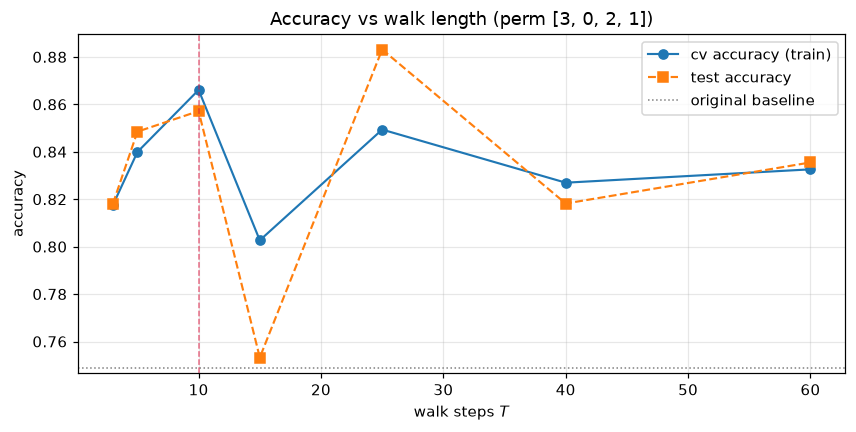

In [18]:
rows = []
for T_i in T_GRID:
    cv_acc = cross_val_score(
        Pipeline([("space", build_space("original+qw", n_steps=T_i, permutation=best_perm)),
                  ("model", make_model())]),
        X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1).mean()
    rows.append((T_i, cv_acc, test_acc[(best_perm, T_i)]))

print(f"permutation fixed at {list(best_perm)}\n")
print(f"{'T':>4}{'cv acc':>10}{'test acc':>11}")
print("-" * 25)
for T_i, c_, t_ in rows:
    print(f"{T_i:>4}{c_:>10.4f}{t_:>11.4f}{'   <- jointly selected' if T_i == best_T else ''}")

fig, ax = plt.subplots()
ax.plot(T_GRID, [r[1] for r in rows], "o-", lw=1.4, label="cv accuracy (train)")
ax.plot(T_GRID, [r[2] for r in rows], "s--", lw=1.4, label="test accuracy")
ax.axhline(results[0]["accuracy"], color="gray", ls=":", lw=1, label="original baseline")
ax.axvline(best_T, color="crimson", ls="--", lw=1, alpha=0.6)
ax.set_xlabel("walk steps $T$"); ax.set_ylabel("accuracy")
ax.set_title(f"Accuracy vs walk length (perm {list(best_perm)})"); ax.legend()
plt.show()

## 10. Final configuration

`T` and the permutation come from the single joint cross-validated search in
section 8, using training data only. These are the numbers to report.

In [19]:
final = [evaluate_space(s, n_steps=best_T, permutation=best_perm) for s in SPACES]
print(f"dataset={DATASET}  seed={SEED}  T={best_T}  perm={list(best_perm)}  selector={SELECTOR}")
print(f"[{describe_permutation(best_perm)}]  (jointly chosen by CV on train only)\n")
print(results_table(final))

base = dict((r["space"], r["accuracy"]) for r in final)["original"]
print(f"\nmajority-class baseline: {max(y_test.mean(), 1 - y_test.mean()):.4f}")
for r in final:
    if r["space"] != "original":
        print(f"  {r['space']:<14} vs original: {r['accuracy'] - base:+.4f}")

dataset=diabetes  seed=42  T=10  perm=[3, 0, 2, 1]  selector=mutual_info
[theta<-f3 phi<-f0 alpha<-f2 beta<-f1]  (jointly chosen by CV on train only)

space           dims   accuracy       f1  precision   recall
------------------------------------------------------------
original           8     0.7489   0.6184     0.6620   0.5802
polynomial        44     0.8225   0.7248     0.7941   0.6667
qw                10     0.8182   0.7439     0.7349   0.7531
original+qw       18     0.8571   0.7950     0.8000   0.7901 *

majority-class baseline: 0.6494
  polynomial     vs original: +0.0736
  qw             vs original: +0.0693
  original+qw    vs original: +0.1082


## Notes and honest caveats

**On methodology.** Feature selection, the min-max scaler, the permutation and
`T` are all fitted or chosen using training data only. The test set is touched
once per reported number. The single most common way to inflate results here is
to loop over the 24 permutations and keep the best test score — section 8
measures exactly how much that would have added.

**On the physics.** The lattice grows with the walk and is always exactly the
light cone, $2T+1$ sites, so no padding is needed and nothing can wrap. The
classic failure mode is a *fixed* array with a non-periodic shift and the walker
at index 0: amplitude then falls off the edge every step, $\sum_x P_T(x)$ decays
far below 1, and the walk stops being unitary. Section 4 catches that
immediately; re-run it after any change to the walk.

**Scope.** This is the **1D case only** — 4 parameters, one coin. The 2D
extension (10 parameters, two coins, a $\mu/\chi$ entangled initial state) is
not implemented here. The structure supports it: `PARAM_NAMES`, `PARAM_RANGES`
and `N_PARAMS` drive the selection width and the mapping, and
`QuantumWalkFeatures` reads all three, so a 2D walk needs a new `run_walk_2d`
plus updated constants rather than a new pipeline.

**Switching datasets.** Set `DATASET` in the config cell to `"diabetes"`,
`"breast_cancer"` or `"spam"` and re-run. Put the matching CSV next to the
notebook; if none is found the notebook falls back to scikit-learn's built-in
Breast Cancer Wisconsin so it always runs.